In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Loading the data

In [2]:
df = pd.read_csv('IHSG_full_history_1990.csv', skiprows=2)

df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df.sort_index()

# 2. Defining the period of dates

In [3]:
presidents = [
    {"name": "Suharto", "start": "1990-04-06", "end": "1998-05-21", "color": "#d4af37"},
    {"name": "Habibie", "start": "1998-05-21", "end": "1999-10-20", "color": "#8ebf42"},
    {"name": "Gus Dur", "start": "1999-10-20", "end": "2001-07-23", "color": "#2e7d32"},
    {"name": "Megawati", "start": "2001-07-23", "end": "2004-10-20", "color": "#c62828"},
    {"name": "SBY", "start": "2004-10-20", "end": "2014-10-20", "color": "#1565c0"},
    {"name": "Jokowi", "start": "2014-10-20", "end": "2024-10-20", "color": "#b71c1c"},
    {"name": "Prabowo", "start": "2024-10-20", "end": "2026-02-08", "color": "#ef6c00"}
]

# 3. Plotting

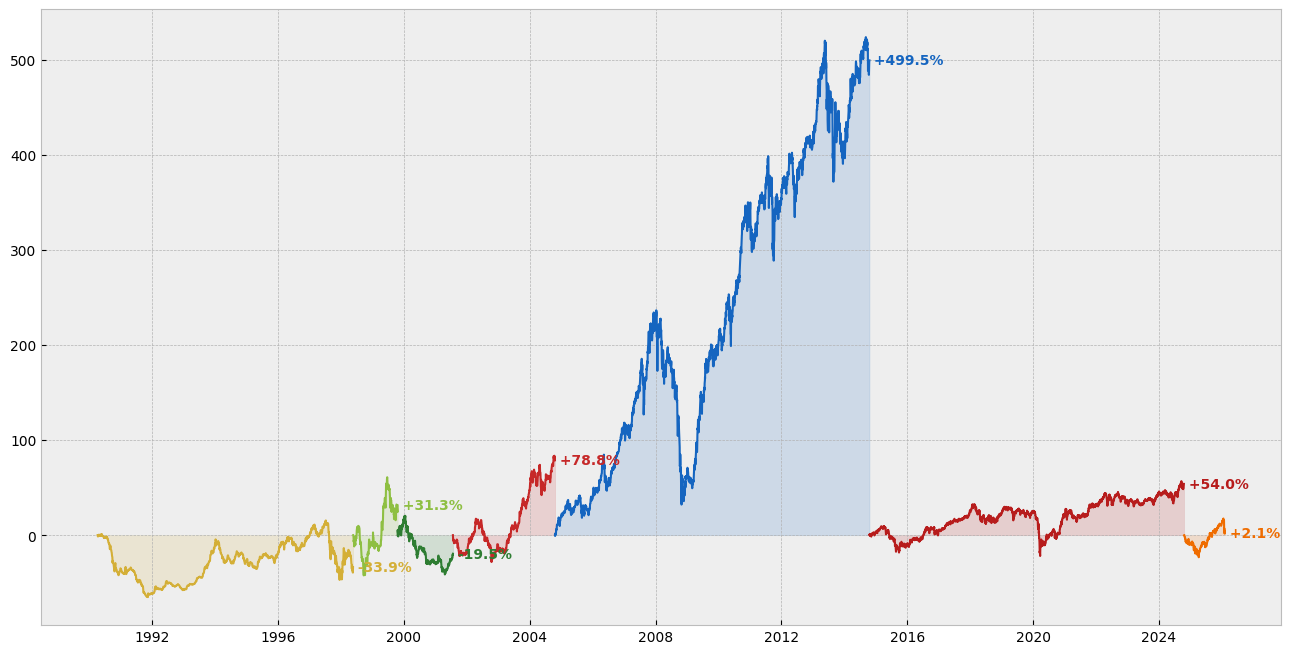

In [ ]:
plt.figure(figsize=(16, 8), facecolor='white')
plt.style.use('bmh')

for p in presidents:
    term_data = df.loc[p['start']:p['end']].copy()
    
    if not term_data.empty:
        initial_price = term_data['Close'].iloc[0]
        # compute cumulative return starting at 1.0 so we can use a log scale
        term_data['Return'] = term_data['Close'] / initial_price
        
        plt.plot(term_data.index, term_data['Return'], color=p['color'], lw=1.5, label=p['name'])
        plt.fill_between(term_data.index, 1, term_data['Return'], color=p['color'], alpha=0.15)
        
        final_val = term_data['Return'].iloc[-1]
        final_pct = (final_val - 1) * 100
        plt.text(term_data.index[-1], final_val, f" {final_pct:+.1f}%", 
                 color=p['color'], fontsize=10, fontweight='bold', va='center')

# use logarithmic scale for the y-axis and label it
plt.yscale('log')
plt.ylabel('Cumulative Return (log scale)')
# show legend for the president labels
plt.legend(title='President')
plt.grid(True)